#**FINAL PROJECT**

#**Diabetes Health Indicators Dataset**

##**Overview**

### This dataset contains 100,000 patient records designed for diabetes risk prediction, analysis, and machine learning applications. The dataset is clean, preprocessed, and ready for use in classification, regression, feature engineering, statistical analysis, and data visualization.

- **age**:
- **gender**:
- **ethnicity**: nguồn gốc dân tộc
- **education_level**:
- **income_level**:
- **employment_status**: Tình trạng việc làm
- **smoking_status**:
- **alcohol_consumption_per_week**: Lượng rượu tiêu thụ mỗi tuần (số ly).

- **physical_activity_minutes_per_week**: Số phút hoạt động thể chất mỗi tuần.
- **diet_score**: Điểm đánh giá chất lượng chế độ ăn uống (điểm càng cao càng lành mạnh).
- **sleep_hours_per_day**: Số giờ ngủ trung bình mỗi ngày.
- **screen_time_hours_per_day**: Số giờ sử dụng màn hình trung bình mỗi ngày.
- **family_history_diabetes**: Tiền sử gia đình mắc bệnh tiểu đường (0 = Không, 1 = Có).
- **hypertension_history**: Tiền sử cao huyết áp (0 = Không, 1 = Có).
- **cardiovascular_history**: Tiền sử bệnh tim mạch (0 = Không, 1 = Có).
- **bmi**: Chỉ số khối cơ thể (Body Mass Index).
- **waist_to_hip_ratio**: Tỷ lệ vòng eo trên vòng hông.
- **systolic_bp**: Huyết áp tâm thu (mmHG).
- **diastolic_bp**: Huyết áp tâm trương (mmHG).
- **heart_rate**: Nhịp tim lúc nghỉ ngơi (bpm).
- **cholesterol_total**: Tổng lượng cholesterol (mg/dL).
- **hdl_cholesterol**: Lượng cholesterol HDL (tốt) (mg/dL).
- **ldl_cholesterol**: Lượng cholesterol LDL (xấu) (mg/dL).
- **triglycerides**: Lượng triglyceride (mg/dL).
- **glucose_fasting**: Lượng đường huyết khi đói (mg/dL).
- **glucose_postprandial**: Lượng đường huyết sau bữa ăn (mg/dL).
- **insulin_level**: Mức insulin trong máu (µU/mL).
- **hba1c**: Chỉ số HbA1c (đo lường lượng đường trong máu trung bình trong 2-3 tháng gần nhất) (%)
- **diabetes_risk_score**: Điểm nguy cơ mắc bệnh tiểu đường (tính toán, từ 0-100).
- **diabetes_stage**: Giai đoạn mắc bệnh tiểu đường (Không mắc, Tiền tiểu đường, Loại 1, Loại 2, Thai kỳ).
- **diagnosed_diabetes**: Chẩn đoán mắc bệnh tiểu đường (0 = Không, 1 = Có).

## Import Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

In [2]:
link = 'https://drive.google.com/file/d/1T6PpsmKNxfSaVH1SZLjQ8po8ZPg2HN1d/view?usp=sharing'
path = 'https://drive.google.com/uc?id=' + link.split('/')[-2]
pd.set_option('display.max_columns', None)
df = pd.read_csv(path)

In [3]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [4]:
df.shape

(100000, 31)

In [5]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,0.856078,115.799610,75.23249,69.632870,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,0.046837,14.284073,8.20425,8.371954,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,0.670000,90.000000,50.00000,40.000000,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,0.820000,106.000000,70.00000,64.000000,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,0.860000,116.000000,75.00000,70.000000,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,0.890000,125.000000,81.00000,75.000000,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,1.060000,179.000000,110.00000,105.000000,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [6]:
df.describe(include='object')

,gender,ethnicity,education_level,income_level,employment_status,smoking_status,diabetes_stage
count,100000,100000,100000,100000,100000,100000,100000
unique,3,5,4,5,4,3,5
top,Female,White,Highschool,Middle,Employed,Never,Type 2
freq,50216,44997,44891,35152,60175,59813,59774


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

## EDA

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
ethnicity,0
education_level,0
income_level,0
employment_status,0
smoking_status,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
diet_score,0


In [ ]:
numerical_cols = df.select_dtypes( include='number').columns
categorical_cols = df.select_dtypes( exclude='number').columns

In [ ]:
for col in categorical_cols:
  print('=====================================================================')
  print(f'{col}: {df[col].unique()}')

gender: ['Male' 'Female' 'Other']
ethnicity: ['Asian' 'White' 'Hispanic' 'Black' 'Other']
education_level: ['Highschool' 'Graduate' 'Postgraduate' 'No formal']
income_level: ['Lower-Middle' 'Middle' 'Low' 'Upper-Middle' 'High']
employment_status: ['Employed' 'Unemployed' 'Retired' 'Student']
smoking_status: ['Never' 'Former' 'Current']
diabetes_stage: ['Type 2' 'No Diabetes' 'Pre-Diabetes' 'Gestational' 'Type 1']


### Phân tích đơn biến

<Axes: xlabel='age', ylabel='count'>

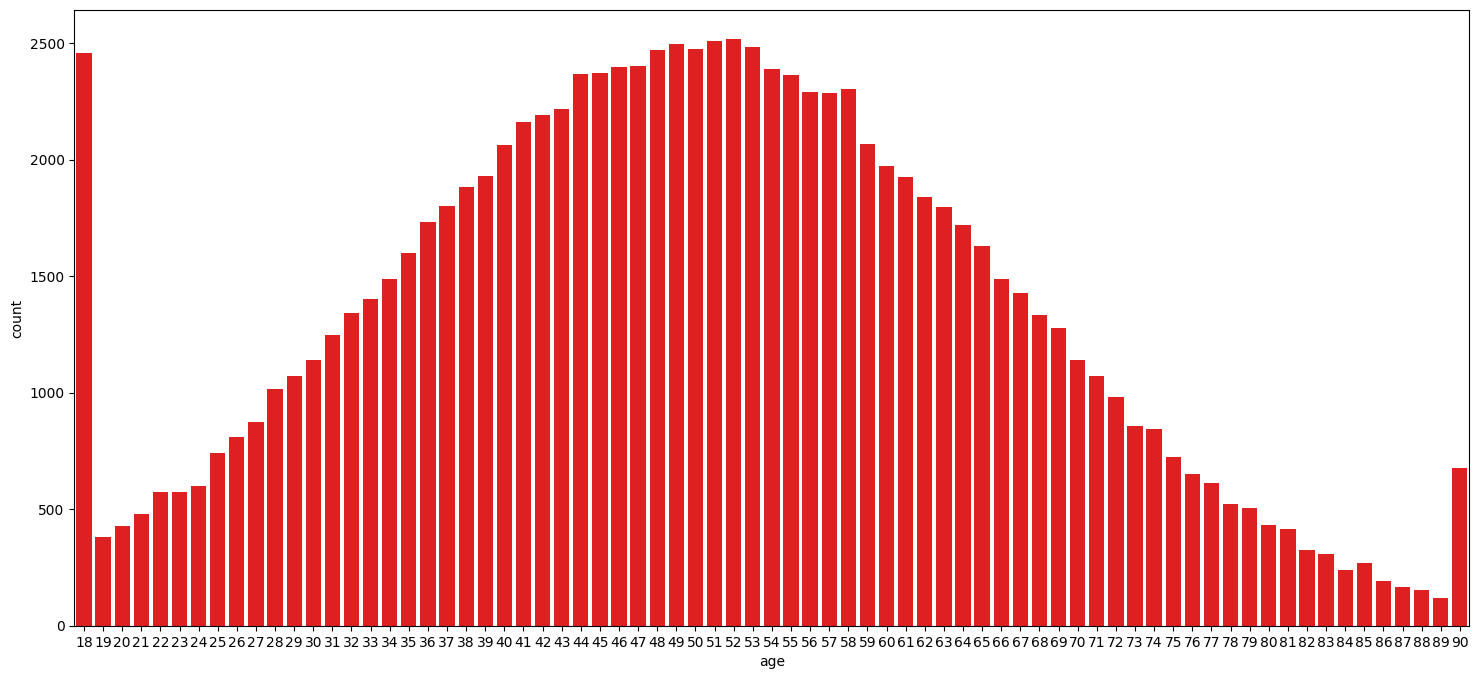

In [ ]:
plt.figure( figsize=(18, 8))
sns.countplot(data=df, x='age', color='red')

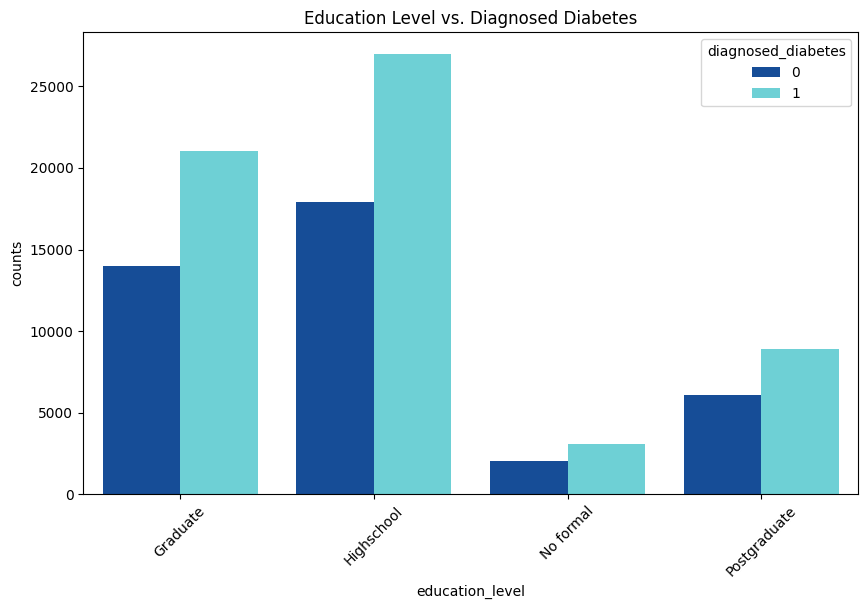

In [ ]:
custom_palette = {0: '#004aad', 1: '#5de0e6'}
edu_diabetes = df.groupby(['education_level', 'diagnosed_diabetes']).size().reset_index(name='counts')
plt.figure(figsize=(10,6))
sns.barplot(x='education_level', y='counts', hue='diagnosed_diabetes', data=edu_diabetes, palette=custom_palette)
plt.title('Education Level vs. Diagnosed Diabetes')
plt.xticks(rotation=45)
plt.show()

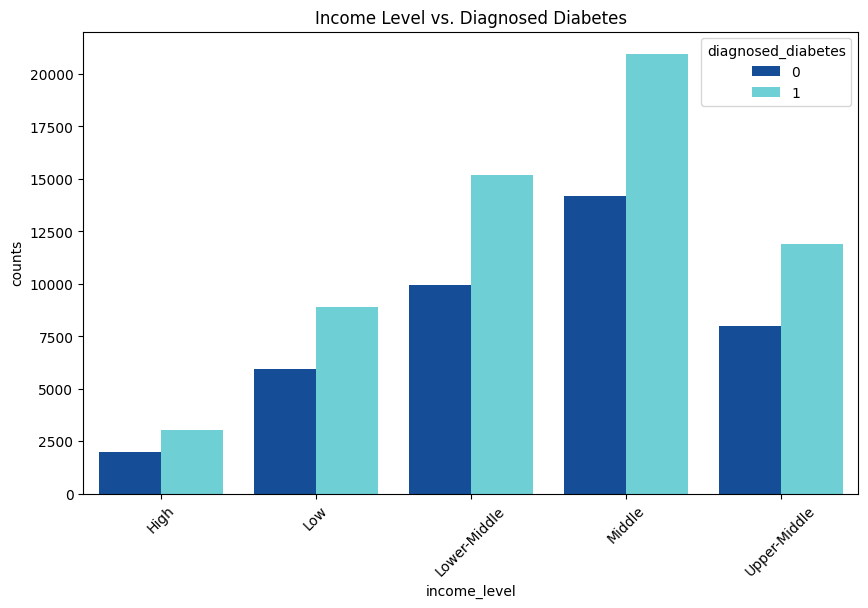

In [ ]:
income_diabetes = df.groupby(['income_level', 'diagnosed_diabetes']).size().reset_index(name='counts')
plt.figure(figsize=(10,6))
sns.barplot(x='income_level', y='counts', hue='diagnosed_diabetes', data=income_diabetes, palette=custom_palette)
plt.title('Income Level vs. Diagnosed Diabetes')
plt.xticks(rotation=45)
plt.show()

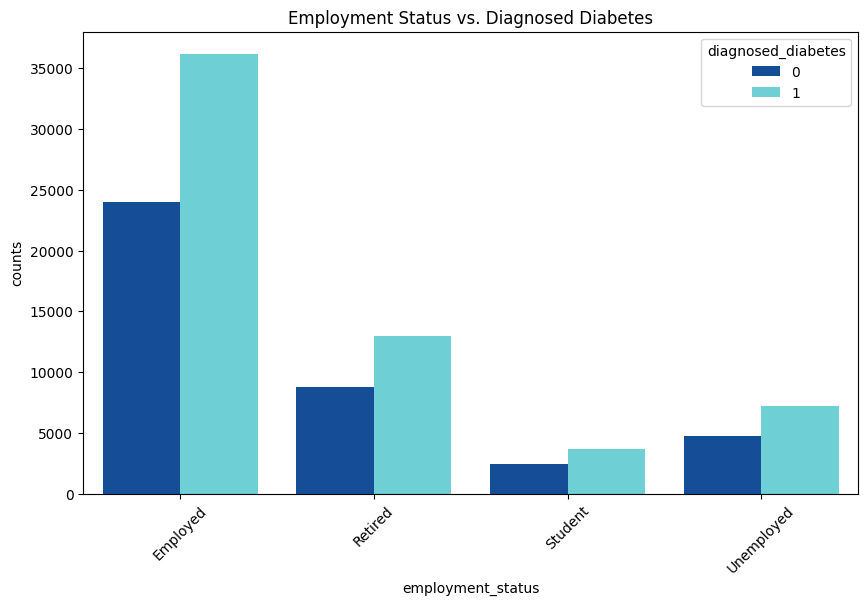

In [ ]:
employ_diabetes = df.groupby(['employment_status', 'diagnosed_diabetes']).size().reset_index(name='counts')
plt.figure(figsize=(10,6))
sns.barplot(x='employment_status', y='counts', hue='diagnosed_diabetes', data=employ_diabetes, palette=custom_palette)
plt.title('Employment Status vs. Diagnosed Diabetes')
plt.xticks(rotation=45)
plt.show()

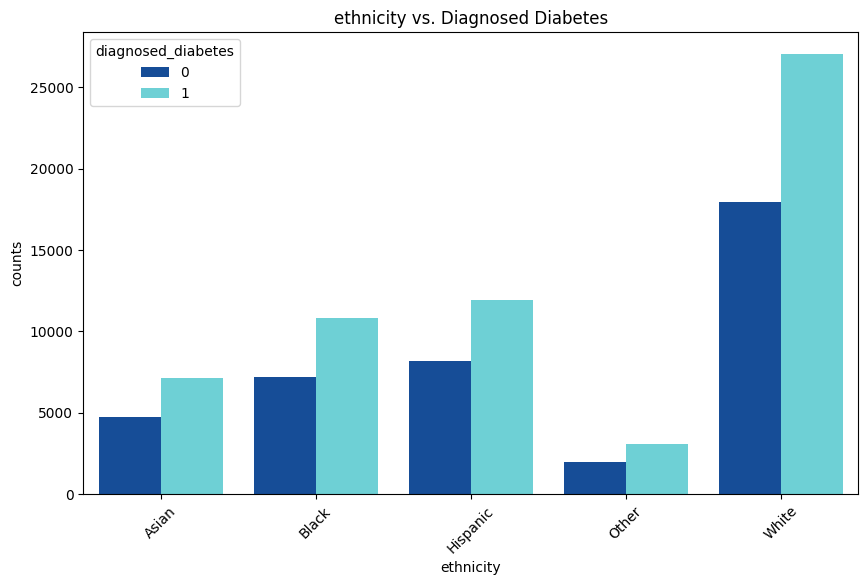

In [ ]:
ethnicity_diabetes = df.groupby(['ethnicity', 'diagnosed_diabetes']).size().reset_index(name='counts')
plt.figure(figsize=(10,6))
sns.barplot(x='ethnicity', y='counts', hue='diagnosed_diabetes', data=ethnicity_diabetes, palette=custom_palette)
plt.title('ethnicity vs. Diagnosed Diabetes')
plt.xticks(rotation=45)
plt.show()

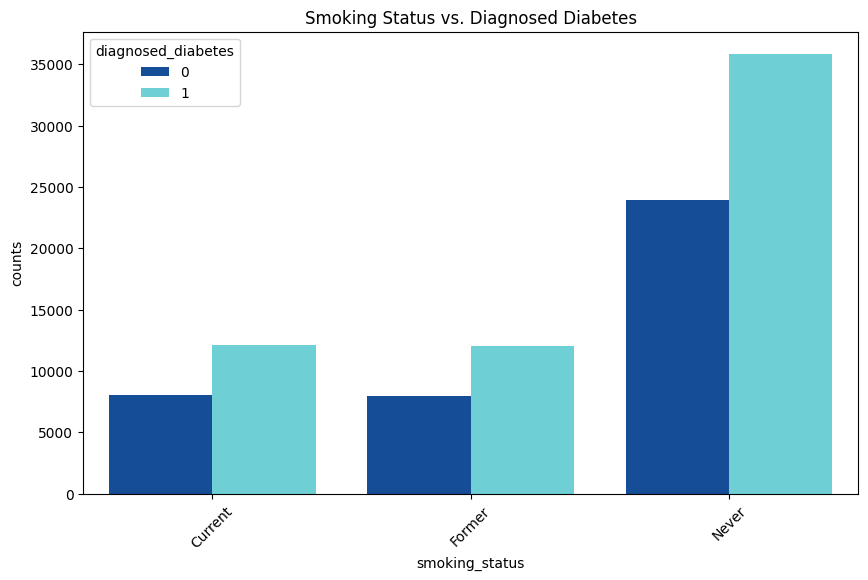

In [ ]:
smoke_diabetes = df.groupby(['smoking_status', 'diagnosed_diabetes']).size().reset_index(name='counts')
plt.figure(figsize=(10,6))
sns.barplot(x='smoking_status', y='counts', hue='diagnosed_diabetes', data=smoke_diabetes, palette=custom_palette)
plt.title('Smoking Status vs. Diagnosed Diabetes')
plt.xticks(rotation=45)
plt.show()

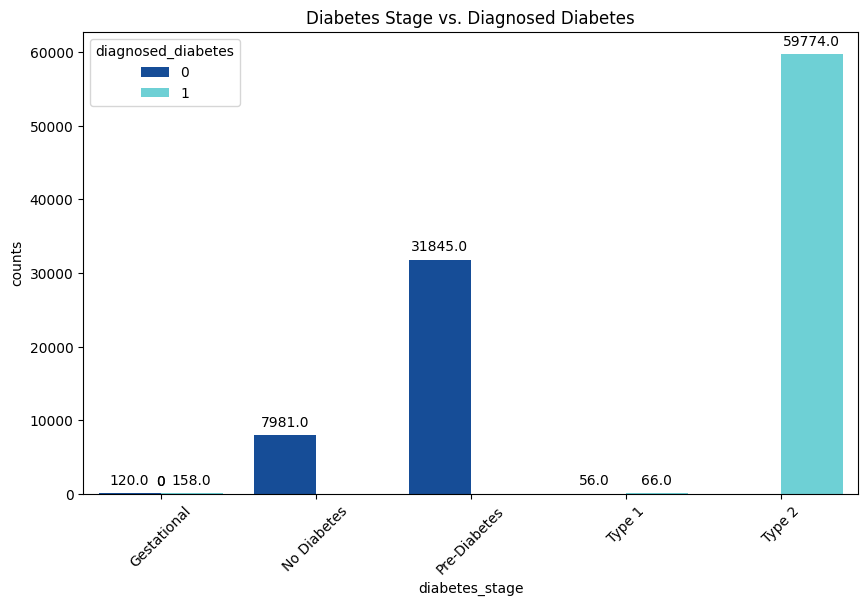

In [ ]:
diabete_stage = df.groupby(['diabetes_stage', 'diagnosed_diabetes']).size().reset_index(name='counts')
plt.figure(figsize=(10,6))
ax = sns.barplot(x='diabetes_stage', y='counts', hue='diagnosed_diabetes', data=diabete_stage, palette=custom_palette)
plt.title('Diabetes Stage vs. Diagnosed Diabetes')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.show()

In [ ]:
df.drop(columns='diabetes_stage', inplace=True)

### Biến định lượng

In [ ]:
print(df['diagnosed_diabetes'].value_counts())

diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64


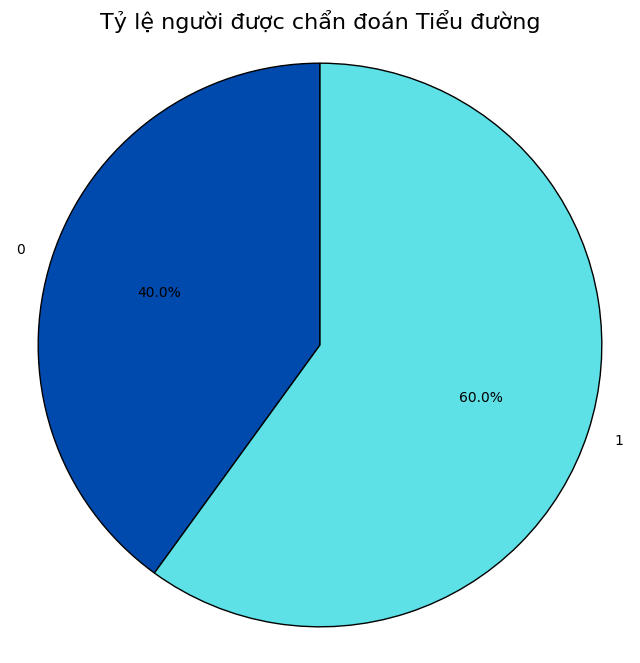

In [ ]:
counts = df['diagnosed_diabetes'].value_counts().sort_index()
labels = ['0', '1']
colors = ['#004aad', '#5de0e6']
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title('Tỷ lệ người được chẩn đoán Tiểu đường', fontsize=16)
plt.axis('equal')
plt.show()

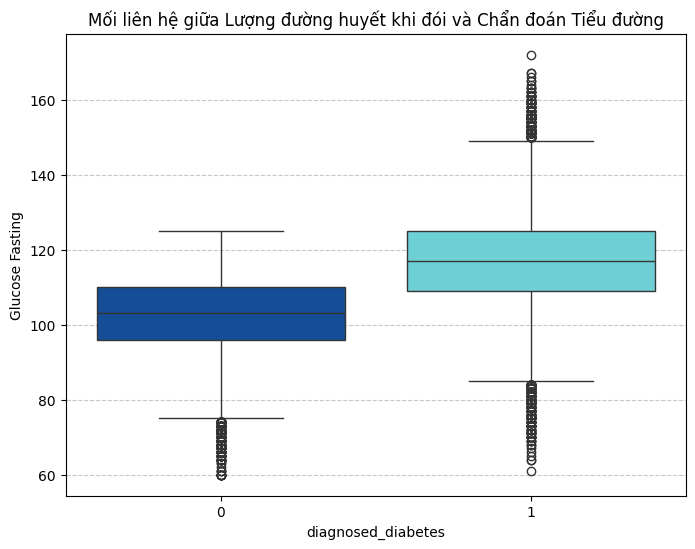

In [ ]:
color_for_0 = '#004aad'
color_for_1 = '#5de0e6'

plt.figure(figsize=(8, 6))
sns.boxplot(x='diagnosed_diabetes', y='glucose_fasting', data=df, palette=[color_for_0, color_for_1])
plt.title('Mối liên hệ giữa Lượng đường huyết khi đói và Chẩn đoán Tiểu đường')
plt.ylabel('Glucose Fasting')
plt.xticks(ticks=[0, 1], labels=['0', '1'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

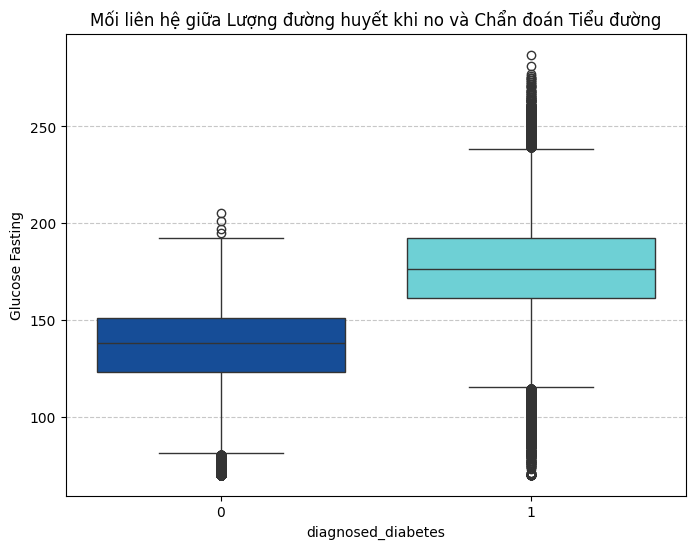

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diagnosed_diabetes', y='glucose_postprandial', data=df, palette=[color_for_0, color_for_1])
plt.title('Mối liên hệ giữa Lượng đường huyết khi no và Chẩn đoán Tiểu đường')
plt.ylabel('Glucose Fasting')
plt.xticks(ticks=[0, 1], labels=['0', '1'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

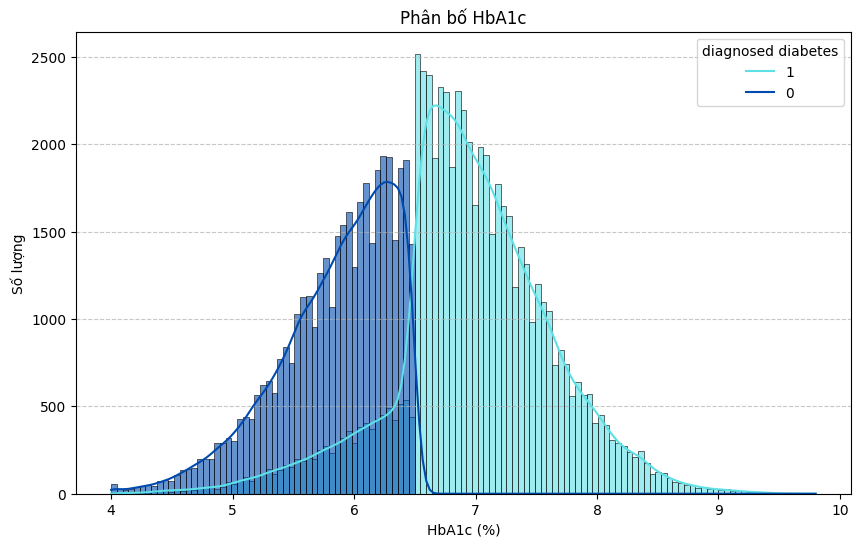

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='hba1c', hue='diagnosed_diabetes', kde=True, palette=['#004aad', '#5de0e6'], alpha=0.6)
plt.title('Phân bố HbA1c')
plt.xlabel('HbA1c (%)')
plt.ylabel('Số lượng')
plt.legend(title='diagnosed diabetes', labels=['1', '0'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


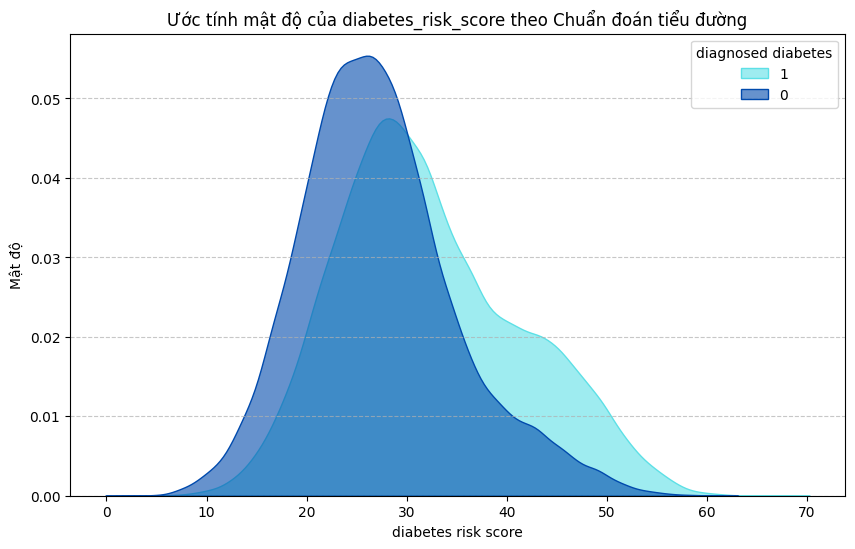

In [9]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='diabetes_risk_score', hue='diagnosed_diabetes', fill=True, common_norm=False, palette=['#004aad', '#5de0e6'], alpha=0.6)
plt.title('Ước tính mật độ của diabetes_risk_score theo Chuẩn đoán tiểu đường')
plt.xlabel('diabetes risk score')
plt.ylabel('Mật độ')
plt.legend(title='diagnosed diabetes', labels=['1', '0'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

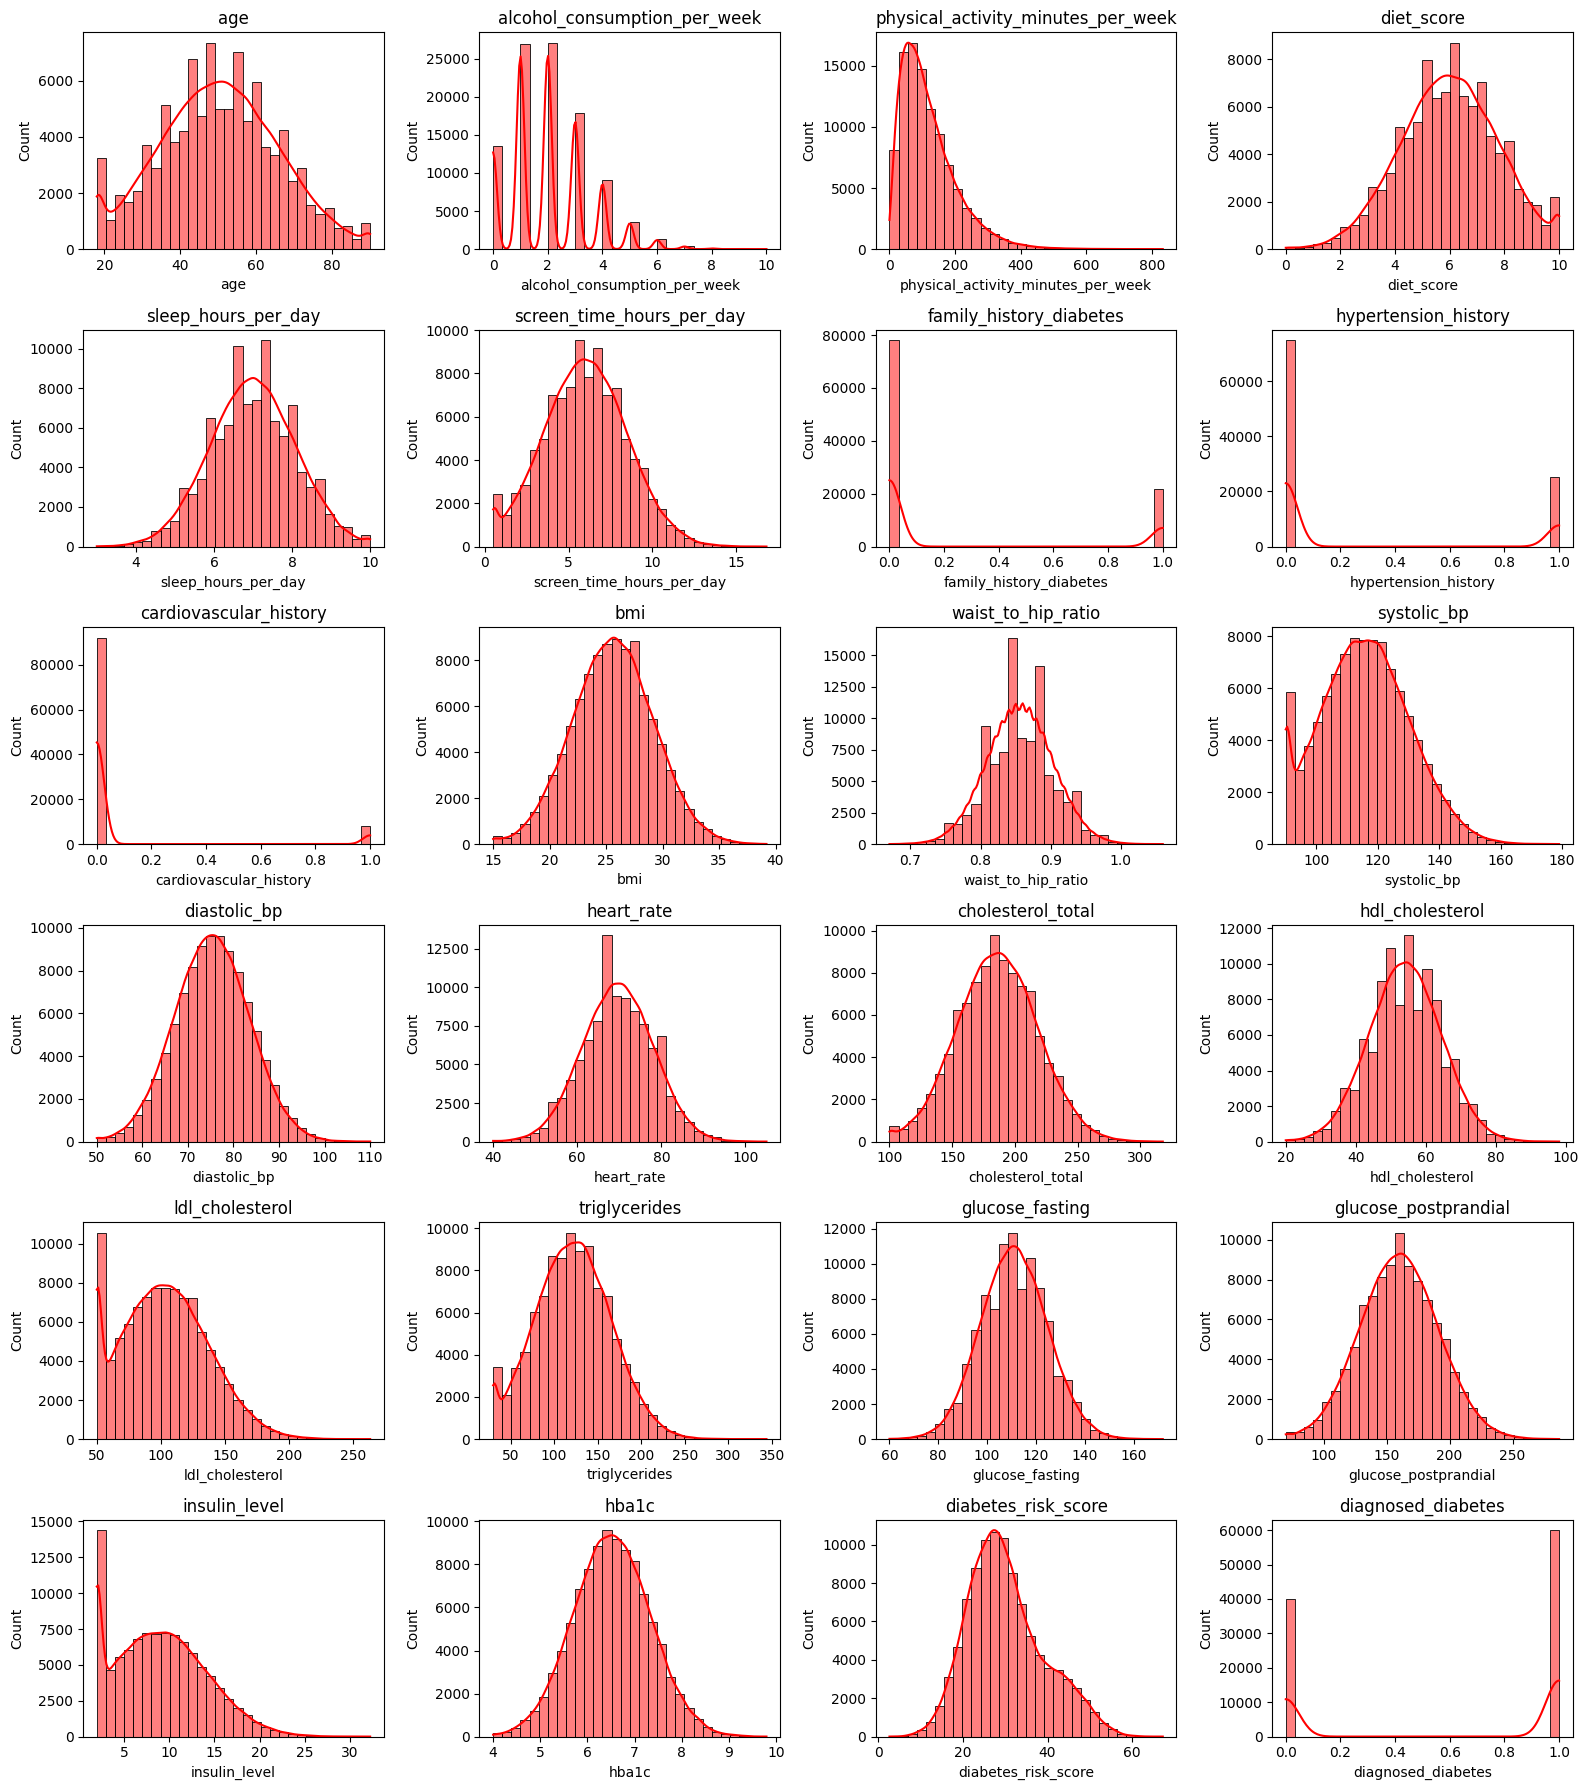

In [ ]:
num_plots = len(numerical_cols)
cols = 4
rows = math.ceil(num_plots / cols)

plt.figure(figsize=(cols * 4, rows * 3))
for idx, col in enumerate(numerical_cols):
    plt.subplot(rows, cols, idx + 1)
    sns.histplot(df[col], kde=True, bins=30, color='red')
    plt.title(col)
plt.tight_layout()
plt.show()

### Phân tích đa biến

<Axes: xlabel='diabetes_risk_score', ylabel='hba1c'>

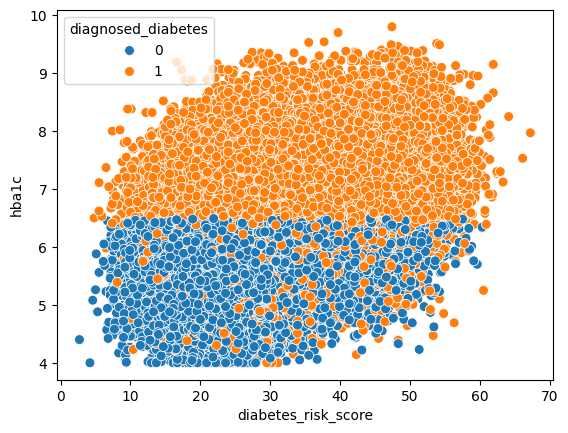

In [ ]:
sns.scatterplot(data=df, x='diabetes_risk_score', y='hba1c', hue='diagnosed_diabetes', s=50)

<Axes: xlabel='physical_activity_minutes_per_week', ylabel='screen_time_hours_per_day'>

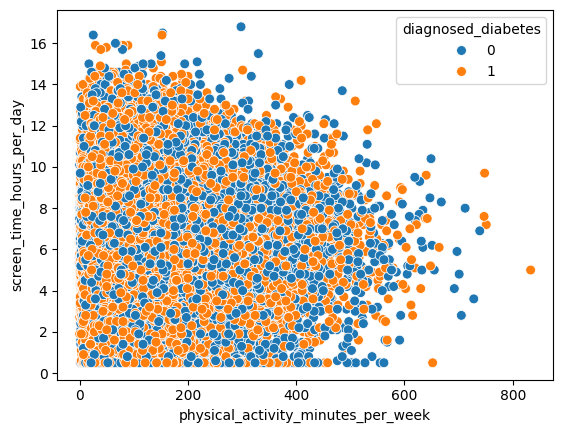

In [ ]:
sns.scatterplot(data=df, x='physical_activity_minutes_per_week', y='screen_time_hours_per_day', hue='diagnosed_diabetes', s=50)

### Heatmap

<Axes: >

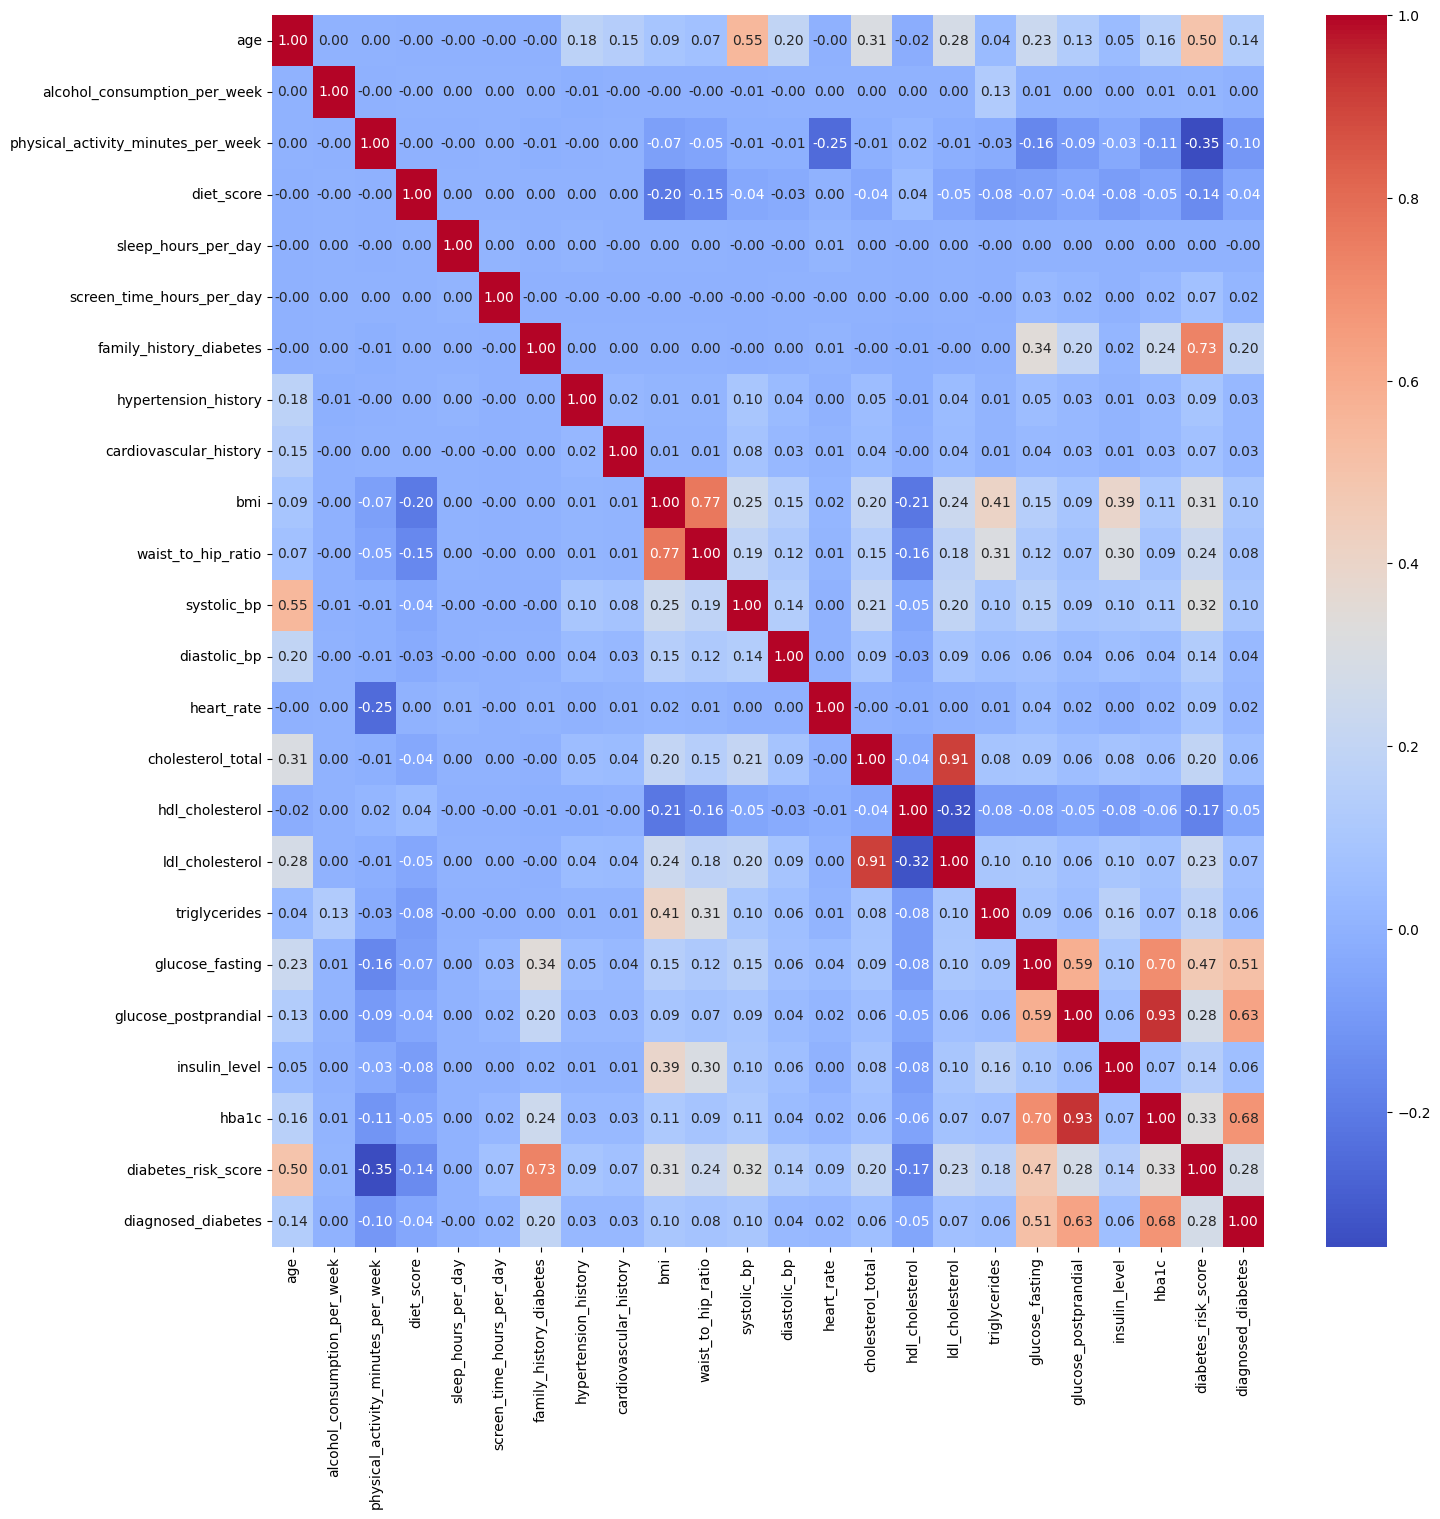

In [ ]:
plt.figure(figsize=(16,16))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap( corr, annot=True, fmt='.2f', cmap='coolwarm')

In [ ]:
numerical_cols = df.select_dtypes( include='number').columns
categorical_cols = df.select_dtypes( exclude='number').columns

print('Numerical Columns: ', numerical_cols)
print('\nCategorical Columns: ', categorical_cols)

Numerical Columns:  Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diagnosed_diabetes'],
      dtype='object')

Categorical Columns:  Index(['gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status'],
      dtype='object')


## Train model with all Features

### Pipeline

In [ ]:
ordinal_cols = {
    'income_level': ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High'],
    'education_level': ['No formal', 'Highschool', 'Graduate', 'Postgraduate']
}

In [ ]:
nominal_cols = ['gender', 'ethnicity', 'employment_status', 'smoking_status']

In [ ]:
numerical_cols = numerical_cols.drop('diagnosed_diabetes')


In [ ]:
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

ordinal_features = list(ordinal_cols.keys())
ordinal_categories = list(ordinal_cols.values())
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=ordinal_categories))
])

nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('ord', ordinal_transformer, ordinal_features),
        ('nom', nominal_transformer, nominal_cols)
    ],
    remainder='passthrough'
)

In [ ]:
X = df.drop('diagnosed_diabetes', axis=1)
y = df['diagnosed_diabetes']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X_train_preprocessor_full = preprocessor.fit_transform(X_train)
X_test_preprocessor_full = preprocessor.transform(X_test)

In [ ]:
X_train.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score
76513,43,Male,Hispanic,Highschool,Lower-Middle,Employed,Never,3,38,5.2,7.3,9.8,0,0,0,29.9,0.89,114,68,64,210,56,138,142,103,184,7.09,6.99,31.0
60406,34,Female,White,Graduate,Middle,Employed,Never,2,112,3.8,7.1,10.2,0,0,0,20.5,0.78,127,65,54,203,58,111,37,104,174,11.56,6.84,20.6
27322,41,Male,Hispanic,Graduate,Middle,Student,Former,0,29,7.9,6.3,8.1,1,0,0,27.4,0.86,115,90,64,207,51,126,132,125,205,8.24,7.48,44.4
53699,70,Male,White,Highschool,Upper-Middle,Unemployed,Never,5,58,6.5,5.7,7.3,1,0,0,28.7,0.90,132,79,69,227,44,145,174,142,206,11.29,7.67,53.9
65412,33,Male,Asian,Graduate,Lower-Middle,Employed,Never,0,80,5.0,8.2,6.8,0,0,0,30.0,0.86,116,79,62,150,45,75,106,133,203,8.58,7.97,26.9


### Logistic Regression


Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86     12067
           1       0.93      0.88      0.90     17933

    accuracy                           0.89     30000
   macro avg       0.88      0.89      0.88     30000
weighted avg       0.89      0.89      0.89     30000


ROC AUC Score: 0.9343


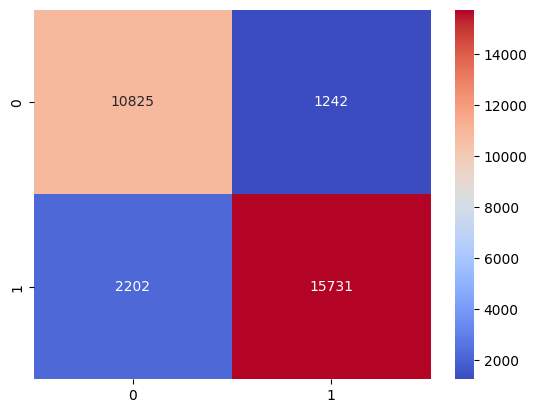

In [ ]:
lr1 = LogisticRegression(random_state=42, class_weight='balanced', solver='lbfgs')
lr1.fit(X_train_preprocessor_full, y_train)
lr1_y_pred_full = lr1.predict(X_test_preprocessor_full)

print("\nClassification Report:\n", classification_report(y_test, lr1_y_pred_full))

sns.heatmap( confusion_matrix(y_test, lr1_y_pred_full), annot=True, cmap='coolwarm', fmt='d')

lr1_y_pred_proba = lr1.predict_proba(X_test_preprocessor_full)[:, 1]
roc_auc = roc_auc_score(y_test, lr1_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

### Decision Tree


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.81      0.82     12067
           1       0.87      0.90      0.89     17933

    accuracy                           0.86     30000
   macro avg       0.86      0.85      0.85     30000
weighted avg       0.86      0.86      0.86     30000


ROC AUC Score: 0.8524


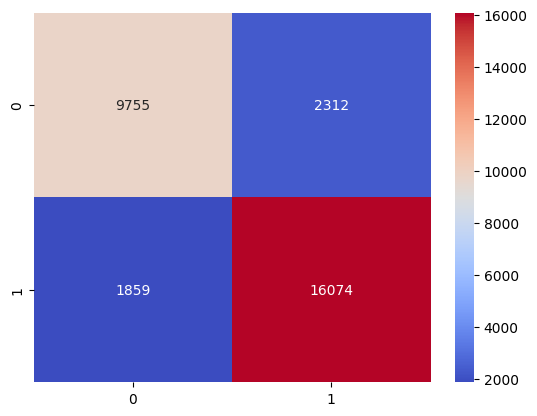

In [ ]:
dt1 = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt1.fit(X_train_preprocessor_full, y_train)
dt1_y_pred_full = dt1.predict(X_test_preprocessor_full)

print("\nClassification Report:\n", classification_report(y_test, dt1_y_pred_full))

sns.heatmap( confusion_matrix(y_test, dt1_y_pred_full), annot=True, cmap='coolwarm', fmt='d')

dt1_y_pred_proba = dt1.predict_proba(X_test_preprocessor_full)[:, 1]
roc_auc = roc_auc_score(y_test, dt1_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

### Random Forest


Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91     12067
           1       1.00      0.87      0.93     17933

    accuracy                           0.92     30000
   macro avg       0.92      0.93      0.92     30000
weighted avg       0.93      0.92      0.92     30000


ROC AUC Score: 0.9427


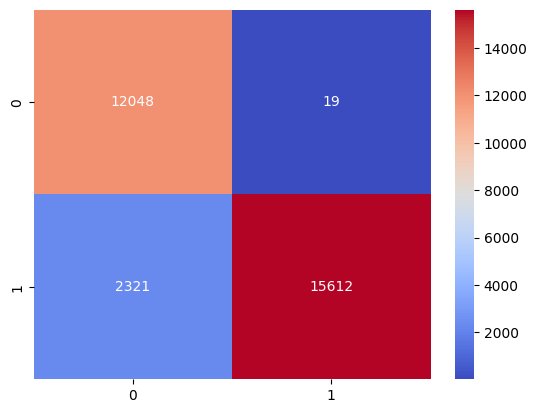

In [ ]:
rf1 = RandomForestClassifier(random_state=42, class_weight='balanced')
rf1.fit(X_train_preprocessor_full, y_train)
rf1_y_pred_full = rf1.predict(X_test_preprocessor_full)

print("\nClassification Report:\n", classification_report(y_test, rf1_y_pred_full))

sns.heatmap( confusion_matrix(y_test, rf1_y_pred_full), annot=True, cmap='coolwarm', fmt='d')

rf1_y_pred_proba = rf1.predict_proba(X_test_preprocessor_full)[:, 1]
roc_auc = roc_auc_score(y_test, rf1_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

### XGBoost


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.99      0.91     12067
           1       0.99      0.87      0.93     17933

    accuracy                           0.92     30000
   macro avg       0.92      0.93      0.92     30000
weighted avg       0.93      0.92      0.92     30000


ROC AUC Score: 0.9422


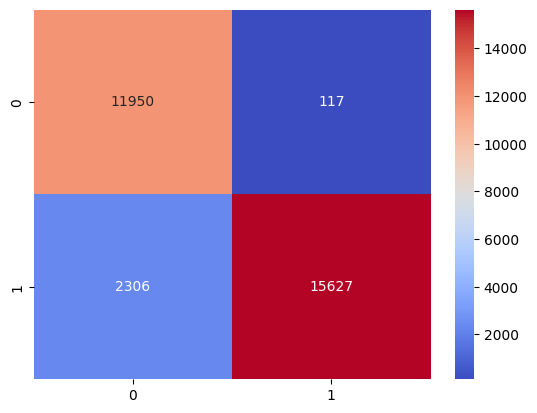

In [ ]:
xgb1 = xgb.XGBClassifier(random_state=42)
xgb1.fit(X_train_preprocessor_full, y_train)
xgb1_y_pred_full = xgb1.predict(X_test_preprocessor_full)

print("\nClassification Report:\n", classification_report(y_test, xgb1_y_pred_full))

sns.heatmap( confusion_matrix(y_test, xgb1_y_pred_full), annot=True, cmap='coolwarm', fmt='d')

xgb1_y_pred_proba = xgb1.predict_proba(X_test_preprocessor_full)[:, 1]
roc_auc = roc_auc_score(y_test, xgb1_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

## Train model with All Features + SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_preprocessor_full, y_train)

### Logistic Regression


--- Logistic Regression with SMOTE ---

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86     12067
           1       0.92      0.88      0.90     17933

    accuracy                           0.88     30000
   macro avg       0.88      0.89      0.88     30000
weighted avg       0.89      0.88      0.88     30000


ROC AUC Score: 0.9342


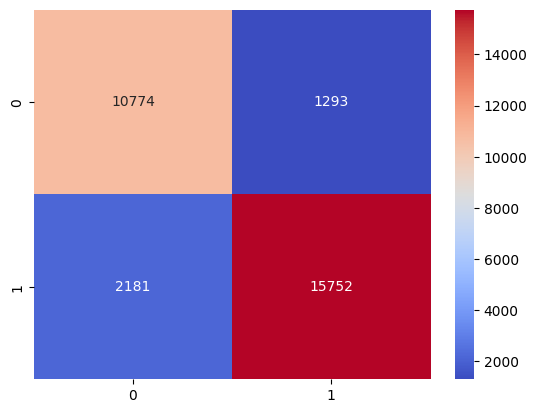

In [ ]:
lr2 = LogisticRegression(random_state=42, class_weight='balanced', solver='lbfgs')
lr2.fit(X_train_smote, y_train_smote)
lr2_y_pred_full = lr2.predict(X_test_preprocessor_full)

print("\n--- Logistic Regression with SMOTE ---")
print("\nClassification Report:\n", classification_report(y_test, lr2_y_pred_full))

sns.heatmap(confusion_matrix(y_test, lr2_y_pred_full), annot=True, cmap='coolwarm', fmt='d')

lr2_y_pred_proba = lr2.predict_proba(X_test_preprocessor_full)[:, 1]
roc_auc = roc_auc_score(y_test, lr2_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

plt.show()

### Decision Tree


--- Decision Tree with SMOTE ---

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.82      0.83     12067
           1       0.88      0.90      0.89     17933

    accuracy                           0.87     30000
   macro avg       0.86      0.86      0.86     30000
weighted avg       0.86      0.87      0.86     30000


ROC AUC Score: 0.8576


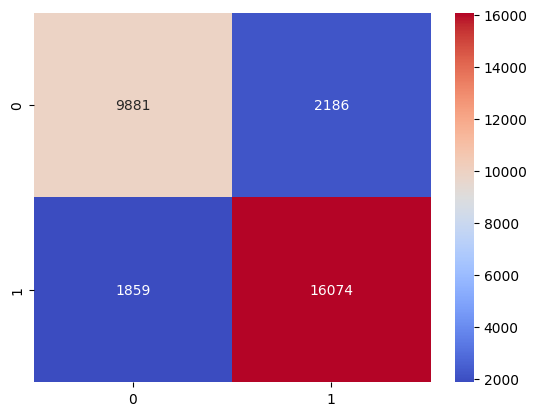

In [ ]:
dt2 = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt2.fit(X_train_smote, y_train_smote)
dt2_y_pred_full = dt2.predict(X_test_preprocessor_full)

print("\n--- Decision Tree with SMOTE ---")
print("\nClassification Report:\n", classification_report(y_test, dt2_y_pred_full))

sns.heatmap(confusion_matrix(y_test, dt2_y_pred_full), annot=True, cmap='coolwarm', fmt='d')

dt2_y_pred_proba = dt2.predict_proba(X_test_preprocessor_full)[:, 1]
roc_auc = roc_auc_score(y_test, dt2_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

plt.show()

### Random Forest


--- Random Forest with SMOTE ---

Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91     12067
           1       1.00      0.87      0.93     17933

    accuracy                           0.92     30000
   macro avg       0.92      0.93      0.92     30000
weighted avg       0.93      0.92      0.92     30000


ROC AUC Score: 0.9419


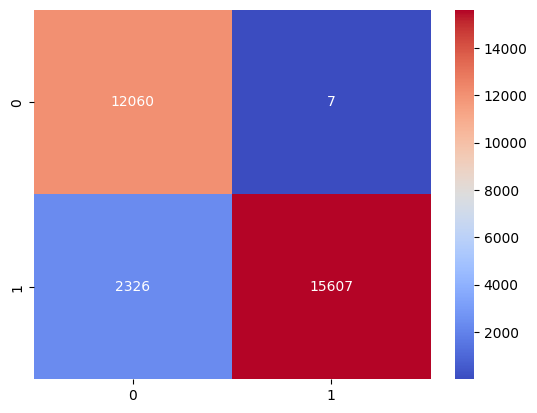

In [ ]:
rf2 = RandomForestClassifier(random_state=42)
rf2.fit(X_train_smote, y_train_smote)
rf2_y_pred_full = rf2.predict(X_test_preprocessor_full)

print("\n--- Random Forest with SMOTE ---")
print("\nClassification Report:\n", classification_report(y_test, rf2_y_pred_full))

sns.heatmap(confusion_matrix(y_test, rf2_y_pred_full), annot=True, cmap='coolwarm', fmt='d')

rf2_y_pred_proba = rf2.predict_proba(X_test_preprocessor_full)[:, 1]
roc_auc = roc_auc_score(y_test, rf2_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

plt.show()

### XGBoost


--- XGBoost with SMOTE ---

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.99      0.91     12067
           1       0.99      0.87      0.93     17933

    accuracy                           0.92     30000
   macro avg       0.92      0.93      0.92     30000
weighted avg       0.93      0.92      0.92     30000


ROC AUC Score: 0.9434


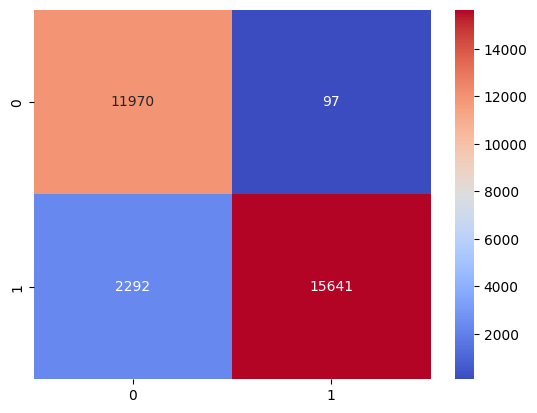

In [ ]:
xgb2 = xgb.XGBClassifier(random_state=42)
xgb2.fit(X_train_smote, y_train_smote)
xgb2_y_pred_full = xgb2.predict(X_test_preprocessor_full)

print("\n--- XGBoost with SMOTE ---")
print("\nClassification Report:\n", classification_report(y_test, xgb2_y_pred_full))

sns.heatmap(confusion_matrix(y_test, xgb2_y_pred_full), annot=True, cmap='coolwarm', fmt='d')

xgb2_y_pred_proba = xgb2.predict_proba(X_test_preprocessor_full)[:, 1]
roc_auc = roc_auc_score(y_test, xgb2_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

plt.show()

## Train Model with Features Selecting

### New Pipeline

In [ ]:
ordinal_cols_map = {
    'income_level': ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High'],
    'education_level': ['No formal', 'Highschool', 'Graduate', 'Postgraduate']
}

original_nominal_cols = ['gender', 'ethnicity', 'employment_status', 'smoking_status']

# --- DANH SÁCH CÁC FEATURES ĐƯỢC CHỌN ---
selected_features = [
    'diabetes_risk_score',
    'hba1c',
    'glucose_fasting',
    'glucose_postprandial',
    'family_history_diabetes'
]

# CHỌN CÁC CỘT TỪ TẬP TRAIN/TEST GỐC
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# ĐỊNH NGHĨA LẠI CÁC DANH SÁCH CỘT CHO PREPROCESSOR DỰA TRÊN selected_features

# Xác định các cột số, thứ tự, định danh từ selected_features
numerical_cols_selected = []
ordinal_features_selected = []
nominal_cols_selected = []

for feature in selected_features:
    if feature in ordinal_cols_map:
        ordinal_features_selected.append(feature)
    elif feature in original_nominal_cols:
        nominal_cols_selected.append(feature)
    else:
        if pd.api.types.is_numeric_dtype(X_train_selected[feature]):
            numerical_cols_selected.append(feature)

# Lấy category order cho các cột thứ tự đã chọn
ordinal_categories_selected = [ordinal_cols_map[col] for col in ordinal_features_selected]


# XÂY DỰNG PIPELINE TIỀN XỬ LÝ MỚI

# Numerical Transformer
numerical_transformer_selected = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Ordinal Transformer
ordinal_transformer_selected = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=ordinal_categories_selected, handle_unknown='use_encoded_value', unknown_value=-1))
])

# Nominal Transformer
nominal_transformer_selected = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer mới
preprocessor_selected = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_selected, numerical_cols_selected),
        ('ord', ordinal_transformer_selected, ordinal_features_selected),
        ('nom', nominal_transformer_selected, nominal_cols_selected)
    ],
    remainder='drop'
)

In [ ]:
X_train_selected.head(2)

,diabetes_risk_score,hba1c,glucose_fasting,glucose_postprandial,family_history_diabetes
76513,31.0,6.99,103,184,0
60406,20.6,6.84,104,174,0


In [ ]:
X_train_preprocessor_selected = preprocessor_selected.fit_transform(X_train_selected)
X_test_preprocessor_selected = preprocessor_selected.transform(X_test_selected)

### Logistic Regression


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.80      0.82     12067
           1       0.87      0.89      0.88     17933

    accuracy                           0.86     30000
   macro avg       0.85      0.85      0.85     30000
weighted avg       0.86      0.86      0.86     30000


ROC AUC Score: 0.9343


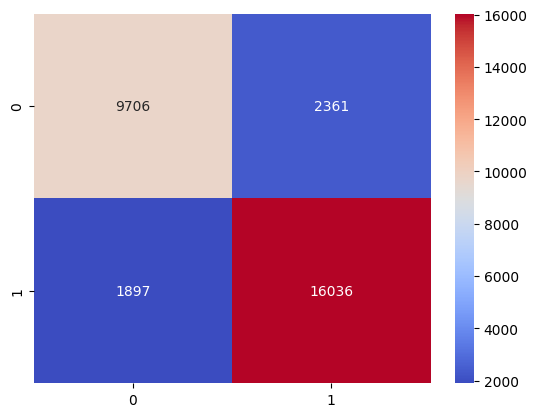

In [ ]:
lr3 = LogisticRegression(random_state=42, solver='lbfgs')
lr3.fit(X_train_preprocessor_selected, y_train)
lr3_y_pred_full = lr3.predict(X_test_preprocessor_selected)

print("\nClassification Report:\n", classification_report(y_test, lr3_y_pred_full))
sns.heatmap( confusion_matrix(y_test,lr3_y_pred_full), annot=True, cmap='coolwarm', fmt='d')

lr3_y_pred_proba = lr3.predict_proba(X_test_preprocessor_selected)[:, 1]
roc_auc = roc_auc_score(y_test, lr3_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

plt.show()

### Decision Tree


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.81      0.83     12067
           1       0.88      0.90      0.89     17933

    accuracy                           0.86     30000
   macro avg       0.86      0.85      0.86     30000
weighted avg       0.86      0.86      0.86     30000


ROC AUC Score: 0.8542


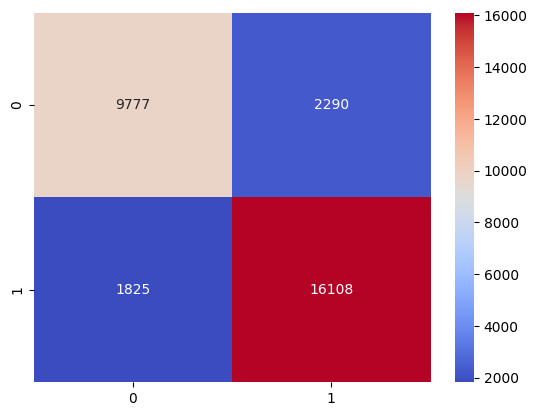

In [ ]:
dt3 = DecisionTreeClassifier(random_state=42)
dt3.fit(X_train_preprocessor_selected, y_train)
dt3_y_pred_full = dt3.predict(X_test_preprocessor_selected)

print("\nClassification Report:\n", classification_report(y_test, dt3_y_pred_full))
sns.heatmap( confusion_matrix(y_test, dt3_y_pred_full), annot=True, cmap='coolwarm', fmt='d')


dt3_y_pred_proba = dt3.predict_proba(X_test_preprocessor_selected)[:, 1]
roc_auc = roc_auc_score(y_test, dt3_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

plt.show()

### Random Forest


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.99      0.91     12067
           1       0.99      0.87      0.93     17933

    accuracy                           0.92     30000
   macro avg       0.92      0.93      0.92     30000
weighted avg       0.93      0.92      0.92     30000


ROC AUC Score: 0.9416


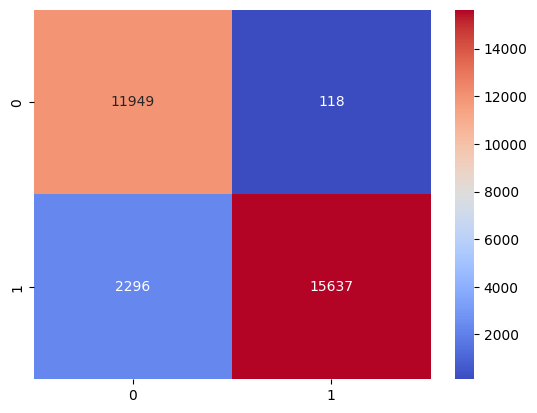

In [ ]:
rf3 = RandomForestClassifier(random_state=42)
rf3.fit(X_train_preprocessor_selected, y_train)
rf3_y_pred_full = rf3.predict(X_test_preprocessor_selected)

print("\nClassification Report:\n", classification_report(y_test, rf3_y_pred_full))

sns.heatmap( confusion_matrix(y_test, rf3_y_pred_full), annot=True, cmap='coolwarm', fmt='d')

rf3_y_pred_proba = rf3.predict_proba(X_test_preprocessor_selected)[:, 1]
roc_auc = roc_auc_score(y_test, rf3_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

plt.show()

### XGBoost


Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91     12067
           1       1.00      0.87      0.93     17933

    accuracy                           0.92     30000
   macro avg       0.92      0.93      0.92     30000
weighted avg       0.93      0.92      0.92     30000


ROC AUC Score: 0.9429


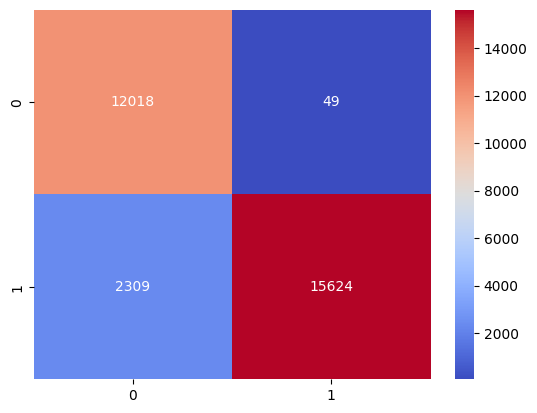

In [ ]:
xgb3 = xgb.XGBClassifier(random_state=42)
xgb3.fit(X_train_preprocessor_selected, y_train)

xgb3_y_pred_full = xgb3.predict(X_test_preprocessor_selected)

print("\nClassification Report:\n", classification_report(y_test, xgb3_y_pred_full))

sns.heatmap( confusion_matrix(y_test, xgb3_y_pred_full), annot=True, cmap='coolwarm', fmt='d')

xgb3_y_pred_proba = xgb3.predict_proba(X_test_preprocessor_selected)[:, 1]
roc_auc = roc_auc_score(y_test, xgb3_y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

plt.show()

## Hyperparameter Tuning

In [ ]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 400],          # Số lượng cây
    'learning_rate': [0.01, 0.1, 0.2],             # Tốc độ học
    'max_depth': [3, 5, 7],                        # Độ sâu tối đa của cây
    'subsample': [0.7, 0.8],                  # Tỷ lệ mẫu con để huấn luyện mỗi cây
    'colsample_bytree': [0.7, 0.8],           # Tỷ lệ đặc trưng con để huấn luyện mỗi cây
    'gamma': [0, 0.1, 0.2],                        # Tham số giảm thiểu loss cần thiết để thực hiện chia cây
    'lambda': [0.5, 1],                         # L2 regularization term on weights
    'alpha': [0.1, 0.2]                         # L1 regularization term on weights
}

In [ ]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    verbose=3,
    n_jobs=-1
)

In [ ]:
print("Starting GridSearchCV for XGBoost...")
# Sử dụng X_train_smote và y_train_smote đã được xử lý bằng SMOTE
grid_search.fit(X_train_smote, y_train_smote)

Starting GridSearchCV for XGBoost...
Fitting 3 folds for each of 1728 candidates, totalling 5184 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'alpha': [0.1, 0.2], 'colsample_bytree': [0.7, 0.8],
                         'gamma': [0, 0.1, 0.2], 'lambda': [0.5, 1],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300, 400],
                         'subsample': [0.7, 0.8]},
             scoring='f1', verbose=3)

In [ ]:
# 5. In ra các siêu tham số tốt nhất và điểm số tốt nhất
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best F1-score (on validation sets): {grid_search.best_score_:.4f}")

# 6. Đánh giá mô hình tốt nhất trên tập kiểm tra
best_xgb_model = grid_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(X_test_preprocessor_full)

print("\n--- Classification Report (Tuned XGBoost) ---")
print(classification_report(y_test, y_pred_tuned))

print("\n--- Confusion Matrix (Tuned XGBoost) ---")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print(cm_tuned)


Best parameters found: {'alpha': 0.2, 'colsample_bytree': 0.7, 'gamma': 0, 'lambda': 0.5, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best F1-score (on validation sets): 0.9292

--- Classification Report (Tuned XGBoost) ---
              precision    recall  f1-score   support

           0       0.84      1.00      0.91     12067
           1       1.00      0.87      0.93     17933

    accuracy                           0.92     30000
   macro avg       0.92      0.94      0.92     30000
weighted avg       0.93      0.92      0.92     30000


--- Confusion Matrix (Tuned XGBoost) ---
[[12067     0]
 [ 2327 15606]]


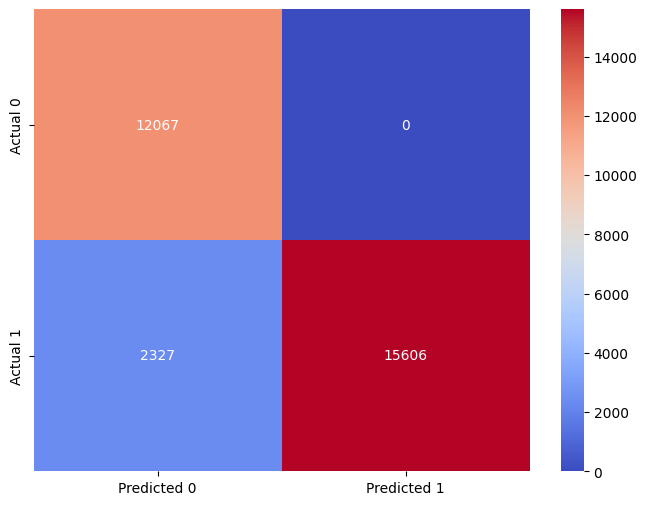

In [ ]:
# Vẽ Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.show()

